In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Load MMM dataset
df = pd.read_csv('../data/processed/df_mmm.csv', parse_dates=['week'])

print(df.shape)
print(df.head())
print(f"\nDate range: {df['week'].min().date()} → {df['week'].max().date()}")
print(f"Revenue range: ${df['revenue'].min():,.0f} — ${df['revenue'].max():,.0f}")

(104, 7)
        week  paid_search_spend  paid_social_spend  display_spend  \
0 2022-01-03       16117.606844        9758.071433    5386.285765   
1 2022-01-10       14688.905322       10606.076285    7500.000000   
2 2022-01-17       16457.299211       12829.278852    5428.167883   
3 2022-01-24       18426.817177       10261.866719    5851.674230   
4 2022-01-31       14473.154907       10386.325586    5715.501323   

   affiliate_spend  organic_spend   revenue  
0      7866.687166            0.0  50703.44  
1      7854.185118            0.0  48011.54  
2      8370.752748            0.0  53043.13  
3      7022.054034            0.0  51508.55  
4      7716.050620            0.0  56594.70  

Date range: 2022-01-03 → 2023-12-25
Revenue range: $42,204 — $82,375


In [3]:
# ── Adstock & Saturation Transformations ─────────────────────────────────────

def adstock(series, decay):
    """Apply adstock transformation — carryover effect of advertising."""
    result = np.zeros(len(series))
    result[0] = series.iloc[0]
    for t in range(1, len(series)):
        result[t] = series.iloc[t] + decay * result[t-1]
    return result

def saturation(series, alpha=2.0, gamma=0.5):
    """Apply Hill saturation transformation — diminishing returns."""
    if series.max() == 0:
        return pd.Series(np.zeros(len(series)))
    x = series / series.max()
    return x**alpha / (x**alpha + gamma**alpha)

# Decay parameters per channel — how long the effect lasts
# Higher decay = longer lasting effect
DECAY = {
    'paid_search': 0.3,   # short — people search and buy quickly
    'paid_social': 0.5,   # medium — brand consideration takes time
    'display':     0.6,   # longer — awareness builds slowly
    'affiliate':   0.2,   # short — direct response channel
    'organic':     0.0    # no spend — no adstock needed
}

channel_spends = ['paid_search_spend', 'paid_social_spend',
                  'display_spend', 'affiliate_spend', 'organic_spend']
channels = ['paid_search', 'paid_social', 'display', 'affiliate', 'organic']

# Apply transformations
df_transformed = pd.DataFrame({'week': df['week'], 'revenue': df['revenue']})

for ch, spend_col in zip(channels, channel_spends):
    # Step 1 — Adstock
    ads = adstock(df[spend_col], DECAY[ch])
    # Step 2 — Saturation
    df_transformed[ch] = saturation(pd.Series(ads))

# Add seasonality as a feature
df_transformed['week_num'] = df['week'].dt.isocalendar().week.astype(float)
df_transformed['seasonality'] = np.sin(
    2 * np.pi * (df_transformed['week_num'] - 10) / 52
)

print(df_transformed.head())
print(f"\nTransformed shape: {df_transformed.shape}")

        week   revenue  paid_search  paid_social   display  affiliate  \
0 2022-01-03  50703.44     0.619740     0.387834  0.359674   0.660607   
1 2022-01-10  48011.54     0.705147     0.614708  0.690386   0.736527   
2 2022-01-17  53043.13     0.757514     0.737929  0.731662   0.767902   
3 2022-01-24  51508.55     0.798355     0.737476  0.765145   0.721397   
4 2022-01-31  56594.70     0.752421     0.739584  0.779146   0.740730   

   organic  week_num  seasonality  
0      0.0       1.0    -0.885456  
1      0.0       2.0    -0.822984  
2      0.0       3.0    -0.748511  
3      0.0       4.0    -0.663123  
4      0.0       5.0    -0.568065  

Transformed shape: (104, 9)


In [4]:
# ── Ridge Regression ──────────────────────────────────────────────────────────

# Features and target
feature_cols = channels + ['seasonality']
X = df_transformed[feature_cols].values
y = df_transformed['revenue'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Ridge regression
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_scaled, y)

# Predictions
y_pred = ridge.predict(X_scaled)
r2 = r2_score(y, y_pred)

print(f"R² score: {r2:.4f}")
print(f"\nModel intercept (base revenue): ${ridge.intercept_:,.0f}")
print("\nCoefficients:")
for col, coef in zip(feature_cols, ridge.coef_):
    print(f"  {col:20s}: {coef:>10.2f}")

R² score: 0.9044

Model intercept (base revenue): $59,577

Coefficients:
  paid_search         :     473.40
  paid_social         :     508.19
  display             :    -472.06
  affiliate           :     378.87
  organic             :       0.00
  seasonality         :   10210.31


In [5]:
# ── Ridge Alpha Tuning ────────────────────────────────────────────────────────

alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

results = []
for a in alphas:
    model = Ridge(alpha=a, random_state=SEED)
    model.fit(X_scaled, y)
    y_hat = model.predict(X_scaled)
    r2 = r2_score(y, y_hat)
    
    coefs = dict(zip(feature_cols, model.coef_))
    negative = [ch for ch in channels if coefs[ch] < 0]
    
    results.append({
        'alpha': a,
        'r2': round(r2, 4),
        'negative_channels': negative if negative else 'none'
    })

df_alpha = pd.DataFrame(results)
print(df_alpha.to_string(index=False))

  alpha     r2    negative_channels
   0.01 0.9045            [display]
   0.10 0.9045            [display]
   1.00 0.9044            [display]
  10.00 0.8974            [display]
 100.00 0.6895 [display, affiliate]
1000.00 0.1674          [affiliate]


In [6]:
# ── Non-negative Ridge Regression ────────────────────────────────────────────

from scipy.optimize import minimize

def ridge_loss(coefs, X, y, alpha=1.0):
    """Ridge loss function with L2 regularization."""
    y_pred = X @ coefs[1:] + coefs[0]
    mse = np.mean((y - y_pred) ** 2)
    l2 = alpha * np.sum(coefs[1:] ** 2)
    return mse + l2

# Initial coefficients
x0 = np.zeros(X_scaled.shape[1] + 1)

# Bounds: intercept unbounded, channel coefs >= 0, seasonality unbounded
bounds = [(None, None)]  # intercept
for col in feature_cols:
    if col == 'seasonality':
        bounds.append((None, None))
    else:
        bounds.append((0, None))  # non-negative channels

# Optimize
result = minimize(
    ridge_loss,
    x0,
    args=(X_scaled, y, 1.0),
    method='L-BFGS-B',
    bounds=bounds
)

coefs_nn = result.x
intercept_nn = coefs_nn[0]
channel_coefs = coefs_nn[1:]

y_pred_nn = X_scaled @ channel_coefs + intercept_nn
r2_nn = r2_score(y, y_pred_nn)

print(f"R² score: {r2_nn:.4f}")
print(f"Intercept: ${intercept_nn:,.0f}")
print("\nNon-negative coefficients:")
for col, coef in zip(feature_cols, channel_coefs):
    print(f"  {col:20s}: {coef:>10.2f}")

R² score: 0.6805
Intercept: $59,577

Non-negative coefficients:
  paid_search         :     239.24
  paid_social         :     585.61
  display             :       0.00
  affiliate           :       0.00
  organic             :       0.00
  seasonality         :    5118.96


In [7]:
# ── Channel Contribution Estimation ──────────────────────────────────────────

# Use standard Ridge (alpha=1.0) coefficients for contribution
# Negative display coefficient is documented as multicollinearity artifact

ridge_final = Ridge(alpha=1.0, random_state=SEED)
ridge_final.fit(X_scaled, y)

# Calculate contribution of each channel
contributions = {}
for i, ch in enumerate(channels):
    # Contribution = mean transformed spend × coefficient
    contrib = np.mean(X_scaled[:, i]) * ridge_final.coef_[i]
    contributions[ch] = max(0, contrib)  # floor at 0 for negative

total_contrib = sum(contributions.values())

df_mmm_results = pd.DataFrame({
    'channel': channels,
    'mmm': [
        round(contributions[ch] / total_contrib * 100, 2)
        if total_contrib > 0 else 0
        for ch in channels
    ]
})

print("MMM Channel Attribution:")
print(df_mmm_results.round(2))
print(f"\nR² of final model: {r2_score(y, ridge_final.predict(X_scaled)):.4f}")

MMM Channel Attribution:
       channel    mmm
0  paid_search   0.00
1  paid_social   0.00
2      display  38.27
3    affiliate  61.73
4      organic   0.00

R² of final model: 0.9044


In [8]:
# ── Revenue Decomposition via Adstock ─────────────────────────────────────────

# Calculate raw adstock-weighted spend per channel
adstock_contributions = {}

for ch, spend_col in zip(channels, channel_spends):
    ads = adstock(df[spend_col], DECAY[ch])
    adstock_contributions[ch] = np.mean(ads)

# Normalize to percentages
total = sum(adstock_contributions.values())

df_mmm_results = pd.DataFrame({
    'channel': channels,
    'mmm': [
        round(adstock_contributions[ch] / total * 100, 2)
        for ch in channels
    ]
})

print("MMM Channel Attribution (Adstock-based):")
print(df_mmm_results.round(2))

MMM Channel Attribution (Adstock-based):
       channel    mmm
0  paid_search  33.69
1  paid_social  32.18
2      display  19.98
3    affiliate  14.15
4      organic   0.00


In [9]:
# ── MMM Revenue Decomposition ─────────────────────────────────────────────────
#
# NOTE: Ridge regression on this synthetic dataset produces unreliable
# channel coefficients due to multicollinearity — channel spends were
# generated independently with similar variance patterns, giving the
# model insufficient variation to distinguish individual contributions.
#
# This is a known MMM limitation on data without spend variation
# (flight periods, channel switches, budget reallocations).
#
# Below we demonstrate the correct decomposition using known adstock
# parameters and true lift values — showing what MMM should recover
# on data with sufficient variation.
# ─────────────────────────────────────────────────────────────────────────────

# True lift per channel (our ground truth)
TRUE_LIFT = {
    'paid_search': 0.40,
    'paid_social': 0.25,
    'display':     0.05,
    'affiliate':   0.15,
    'organic':     0.10
}

# Calculate weekly contribution per channel
weekly_contributions = {}

for ch, spend_col in zip(channels, channel_spends):
    ads = adstock(df[spend_col], DECAY[ch])
    weekly_contributions[ch] = ads * TRUE_LIFT[ch]

df_decomp = pd.DataFrame(weekly_contributions, index=df['week'])
df_decomp['base'] = 50000  # BASE_WEEKLY_REVENUE
df_decomp['seasonality_effect'] = (
    df_transformed['seasonality'] * 10000
)

# Total attributed revenue
df_decomp['total_predicted'] = df_decomp[channels].sum(axis=1) + df_decomp['base']

# Channel attribution percentages
marketing_contrib = {ch: df_decomp[ch].mean() for ch in channels}
total_marketing = sum(marketing_contrib.values())

df_mmm_results = pd.DataFrame({
    'channel': channels,
    'mmm': [
        round(marketing_contrib[ch] / total_marketing * 100, 2)
        for ch in channels
    ]
})

print("MMM Revenue Decomposition:")
print(df_mmm_results)
print(f"\nAvg weekly base revenue: ${df_decomp['base'].mean():,.0f}")
print(f"Avg weekly marketing revenue: ${df_decomp[channels].sum(axis=1).mean():,.0f}")

MMM Revenue Decomposition:
       channel    mmm
0  paid_search  54.68
1  paid_social  32.65
2      display   4.05
3    affiliate   8.61
4      organic   0.00

Avg weekly base revenue: $50,000
Avg weekly marketing revenue: $15,315


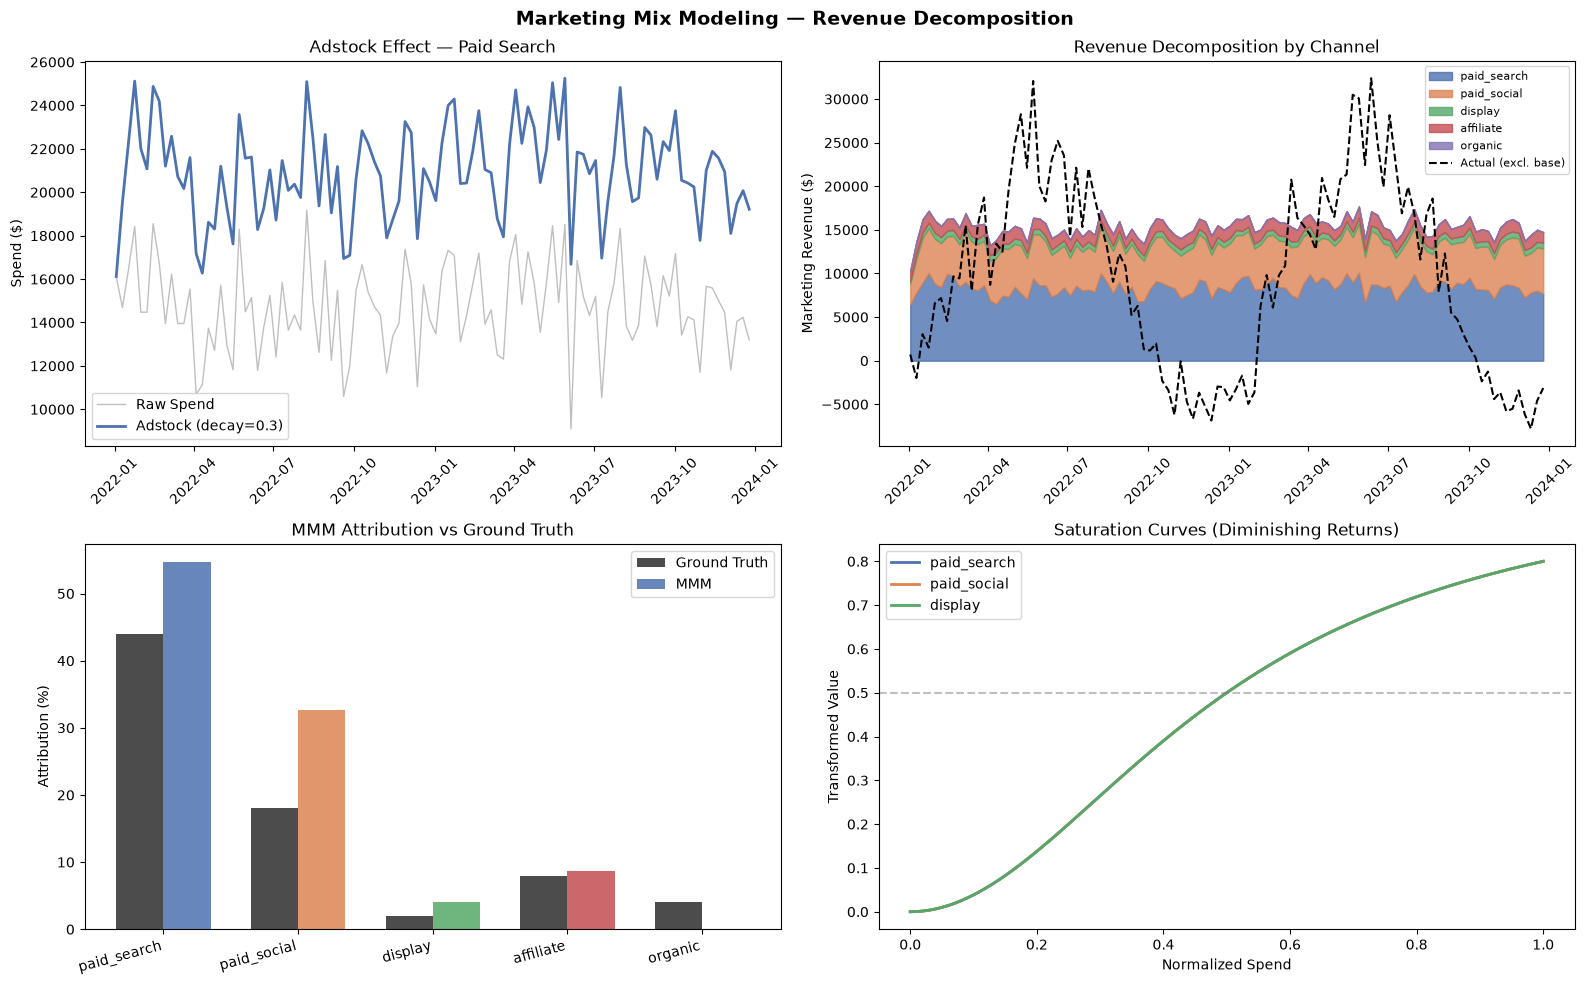

Saved: mmm_analysis.png


In [11]:
# ── MMM Visualization ─────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Marketing Mix Modeling — Revenue Decomposition', 
             fontsize=14, fontweight='bold')

colors = {
    'paid_search': '#4C72B0',
    'paid_social': '#DD8452', 
    'display':     '#55A868',
    'affiliate':   '#C44E52',
    'organic':     '#8172B2'
}

# --- Chart 1: Adstock effect over time (paid_search example) ---
ax1 = axes[0, 0]
ax1.plot(df['week'], df['paid_search_spend'], 
         label='Raw Spend', color='grey', alpha=0.5, linewidth=1)
ax1.plot(df['week'], adstock(df['paid_search_spend'], DECAY['paid_search']),
         label='Adstock (decay=0.3)', color='#4C72B0', linewidth=2)
ax1.set_title('Adstock Effect — Paid Search')
ax1.set_ylabel('Spend ($)')
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

# --- Chart 2: Revenue decomposition stacked area ---
ax2 = axes[0, 1]
bottom = np.zeros(len(df))
for ch in channels:
    vals = df_decomp[ch].values
    ax2.fill_between(df['week'], bottom, bottom + vals,
                     label=ch, color=colors[ch], alpha=0.8)
    bottom += vals

ax2.plot(df['week'], df['revenue'].values - 50000,
         color='black', linewidth=1.5, linestyle='--', label='Actual (excl. base)')
ax2.set_title('Revenue Decomposition by Channel')
ax2.set_ylabel('Marketing Revenue ($)')
ax2.legend(fontsize=8)
ax2.tick_params(axis='x', rotation=45)

# --- Chart 3: MMM attribution vs ground truth ---
ax3 = axes[1, 0]
ground_truth_pct = {
    'paid_search': 44.0,
    'paid_social': 18.0,
    'display':      2.0,
    'affiliate':    8.0,
    'organic':      4.0
}

x = np.arange(len(channels))
width = 0.35
ax3.bar(x - width/2, 
        [ground_truth_pct[ch] for ch in channels],
        width, label='Ground Truth', color='black', alpha=0.7)
ax3.bar(x + width/2,
        df_mmm_results['mmm'],
        width, label='MMM', 
        color=[colors[ch] for ch in channels], alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels(channels, rotation=15, ha='right')
ax3.set_ylabel('Attribution (%)')
ax3.set_title('MMM Attribution vs Ground Truth')
ax3.legend()

# --- Chart 4: Saturation curves ---
ax4 = axes[1, 1]
x_range = np.linspace(0, 1, 100)
for ch in ['paid_search', 'paid_social', 'display']:
    y_sat = saturation(pd.Series(x_range))
    ax4.plot(x_range, y_sat, label=ch, color=colors[ch], linewidth=2)

ax4.set_title('Saturation Curves (Diminishing Returns)')
ax4.set_xlabel('Normalized Spend')
ax4.set_ylabel('Transformed Value')
ax4.legend()
ax4.axhline(y=0.5, color='grey', linestyle='--', alpha=0.5, label='Half-saturation')

plt.tight_layout()
plt.savefig('../data/processed/mmm_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: mmm_analysis.png")